Loading data...
\nZIPF
distribution alpha = 1.5389
zipf exponent = 1.8556
xmin = 3.0
\nHEAPS
burn-in = 53
beta = 0.5494784764592294
95% CI = 0.5494086690068299 0.5495482839116289
\nTAYLOR
Slope = 0.9083117663783806


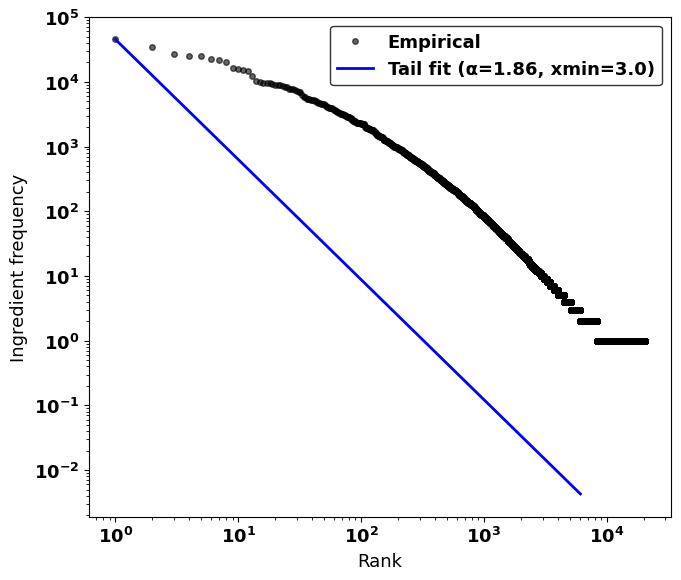

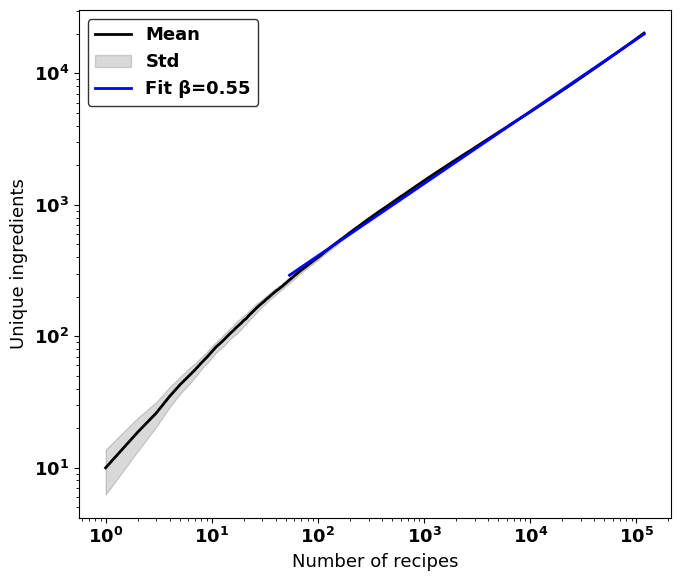

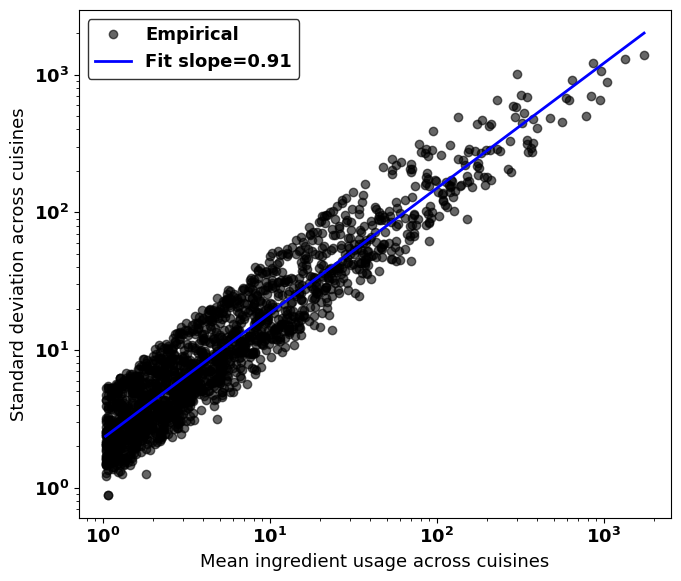

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import powerlaw

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    leg=ax.legend(frameon=True)
    if leg:
        leg.get_frame().set_edgecolor("black")

print("Loading data...")

df_cuisine=pd.read_csv("Datasets/RecipeDB_RecipeID_Cuisine.csv")
df_ing=pd.read_csv("Datasets/RecipeID_Ing_ID.csv")
df_ing.rename(columns={"recipe_no":"Recipe_id"},inplace=True)

df=pd.merge(df_ing,df_cuisine,on="Recipe_id")

# ---------------- ZIPF ---------------- #

counts=df["ing_id"].value_counts().values

fit=powerlaw.Fit(counts,discrete=True,verbose=False)

alpha_dist=fit.alpha
xmin=fit.xmin
alpha_zipf=1/(alpha_dist-1)

tail=counts[counts>=xmin]
tail=np.sort(tail)[::-1]
tail_rank=np.arange(1,len(tail)+1)

C=tail[0]*(tail_rank[0]**alpha_zipf)
fitline=C*tail_rank**(-alpha_zipf)

print("\\nZIPF")
print(f"distribution alpha = {alpha_dist:.4f}")
print(f"zipf exponent = {alpha_zipf:.4f}")
print(f"xmin = {xmin}")

fig,ax=plt.subplots(figsize=(7,6))
ax.loglog(np.arange(1,len(counts)+1),np.sort(counts)[::-1],
          'o',ms=4,color='black',alpha=.6,label="Empirical")
ax.loglog(tail_rank,fitline,'b-',lw=2,
          label=f"Tail fit (α={alpha_zipf:.2f}, xmin={xmin})")
ax.set_xlabel("Rank")
ax.set_ylabel("Ingredient frequency")
format_axes(ax)
plt.tight_layout()
plt.savefig("zipf_law_improved.png",dpi=300)

# ---------------- HEAPS ---------------- #

recipes=df.groupby("Recipe_id")["ing_id"].apply(set).tolist()

sim=30
R=len(recipes)
hist=np.zeros((sim,R))

for i in range(sim):
    order=np.random.permutation(recipes)
    seen=set()
    vals=[]
    for rec in order:
        seen.update(rec)
        vals.append(len(seen))
    hist[i]=vals

x=np.arange(1,R+1)
y=hist.mean(0)
sd=hist.std(0)

best_r2=-1
best_start=0

for start in range(5,min(200,R//2)):
    lx=np.log(x[start:])
    ly=np.log(y[start:])
    b,a=np.polyfit(lx,ly,1)
    pred=a+b*lx
    ssr=((ly-pred)**2).sum()
    sst=((ly-ly.mean())**2).sum()
    r2=1-ssr/sst
    if r2>best_r2:
        best_r2=r2
        best_start=start

lx=np.log(x[best_start:])
ly=np.log(y[best_start:])
beta,inter=np.polyfit(lx,ly,1)

pred=inter+beta*lx
res=ly-pred
n=len(lx)
se=np.sqrt(np.sum(res**2)/(n-2))/np.sqrt(np.sum((lx-lx.mean())**2))
ci=1.96*se

print("\\nHEAPS")
print("burn-in =",best_start)
print("beta =",beta)
print("95% CI =",beta-ci,beta+ci)

fig,ax=plt.subplots(figsize=(7,6))
ax.plot(x,y,'k',lw=2,label="Mean")
ax.fill_between(x,y-sd,y+sd,color='k',alpha=.15,label="Std")
ax.plot(x[best_start:],np.exp(inter)*x[best_start:]**beta,
        'b',lw=2,label=f"Fit β={beta:.2f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of recipes")
ax.set_ylabel("Unique ingredients")
format_axes(ax)
plt.tight_layout()
plt.savefig("heaps_law_improved.png",dpi=300)

# ---------------- TAYLOR ---------------- #

tab=pd.crosstab(df.ing_id,df.Cuisine)

mu=tab.mean(axis=1)
sigma=tab.std(axis=1)

mask=(mu>1)&(sigma>0)
mu=mu[mask]
sigma=sigma[mask]

lx=np.log(mu)
ly=np.log(sigma)

slope,inter=np.polyfit(lx,ly,1)

print("\\nTAYLOR")
print("Slope =",slope)

fig,ax=plt.subplots(figsize=(7,6))
ax.loglog(mu,sigma,'o',color='black',alpha=.6,label="Empirical")
xx=np.linspace(mu.min(),mu.max(),200)
ax.loglog(xx,np.exp(inter)*xx**slope,'b',lw=2,
          label=f"Fit slope={slope:.2f}")
ax.set_xlabel("Mean ingredient usage across cuisines")
ax.set_ylabel("Standard deviation across cuisines")
format_axes(ax)
plt.tight_layout()
plt.savefig("taylor_law_improved.png",dpi=300)

plt.show()


Loading data...

===== Menzerath–Altmann Fit =====
A = 13.06270 ± 0.13048
b = -0.25165 ± 0.00744
c = -0.01821 ± 0.00064
R² = 0.9764
No finite physical peak exists. The fitted curve decreases initially and then increases because c<0.


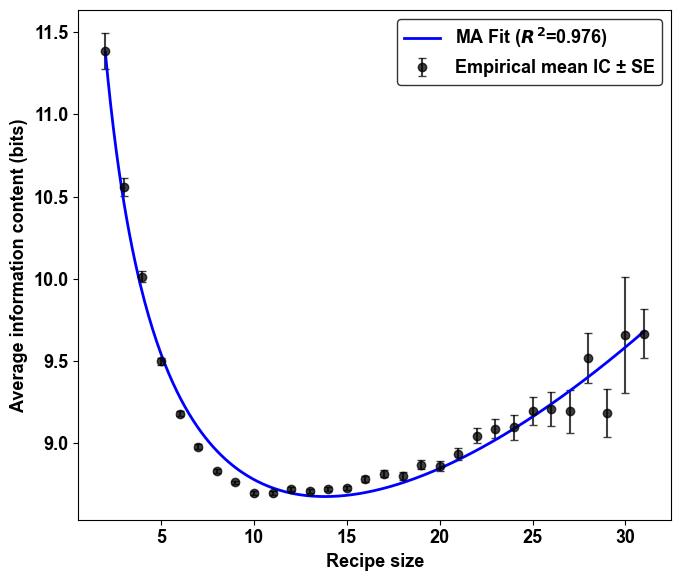

In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------------- Plot Style ---------------- #
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    leg = ax.legend(frameon=True)
    if leg:
        leg.get_frame().set_edgecolor("black")

# ---------------- Load Data ---------------- #
print("Loading data...")

df = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")

# ---------- Shannon Information ---------- #
counts = df["ing_id"].value_counts()
prob = counts / len(df)

df["prob"] = df["ing_id"].map(prob)
df["IC"] = -np.log2(df["prob"])

# ---------- Recipe statistics ---------- #
recipe_stats = df.groupby("recipe_no").agg(
    recipe_size=("ing_id", "count"),
    mean_ic=("IC", "mean")
)

# Keep original aggregation (correct for fixed recipe length)
group = recipe_stats.groupby("recipe_size")

ma_data = group.agg(
    mean_ic=("mean_ic", "mean"),
    std=("mean_ic", "std"),
    n=("mean_ic", "count")
).reset_index()

ma_data["se"] = ma_data["std"] / np.sqrt(ma_data["n"])

# Original threshold retained
ma_data = ma_data[ma_data["n"] >= 10].copy()

x = ma_data["recipe_size"].values
y = ma_data["mean_ic"].values
sigma = ma_data["se"].fillna(ma_data["se"].median()).values

# ---------------- MA Model ---------------- #
def menzerath_altmann(x, A, b, c):
    return A * (x ** b) * np.exp(-c * x)

p0 = [y.max(), -0.1, -0.01]

popt, pcov = curve_fit(
    menzerath_altmann,
    x,
    y,
    p0=p0,
    maxfev=20000
)

A, b, c = popt
perr = np.sqrt(np.diag(pcov))

# ---------------- Goodness of fit ---------------- #
pred = menzerath_altmann(x, *popt)

ss_res = np.sum((y - pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

print("\n===== Menzerath–Altmann Fit =====")
print(f"A = {A:.5f} ± {perr[0]:.5f}")
print(f"b = {b:.5f} ± {perr[1]:.5f}")
print(f"c = {c:.5f} ± {perr[2]:.5f}")
print(f"R² = {r2:.4f}")

if b>0 and c>0:
    peak = -b / c
    print(f"L* = {-b/c:.3f}")
    if peak >= x.min() and peak <= x.max():
        print("Peak lies inside observed range.")
    else:
        print("Peak lies outside observed range.")
else:
    print("No finite physical peak exists. The fitted curve decreases initially and then increases because c<0.")

# ---------------- Plot ---------------- #
fig, ax = plt.subplots(figsize=(7,6))

ax.errorbar(
    x,
    y,
    yerr=sigma,
    fmt='o',
    color='black',
    capsize=3,
    alpha=0.75,
    label='Empirical mean IC ± SE'
)

xx = np.linspace(x.min(), x.max(), 400)
ax.plot(
    xx,
    menzerath_altmann(xx, *popt),
    color='blue',
    linewidth=2,
    label=f'MA Fit ($R^2$={r2:.3f})'
)

ax.set_xlabel("Recipe size", fontweight="bold")
ax.set_ylabel("Average information content (bits)", fontweight="bold")

format_axes(ax)
plt.tight_layout()

plt.savefig("menzerath_altmann_recipe_structure.png", dpi=300)
plt.savefig("menzerath_altmann_recipe_structure.tif", dpi=300)

plt.show()


-------------------------------------------------------
R² peak at k:                  11930
Cutoff used (R² peak):         rank = 11930
α (power-law exponent):        1.7510
R² at cutoff:                  0.9839

Note: No sharp elbow detected in R² curve.
Cutoff set at R² peak — the k where OLS fit is best.
-------------------------------------------------------


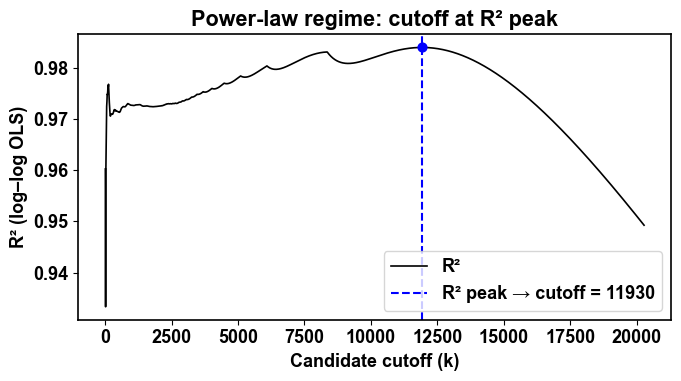

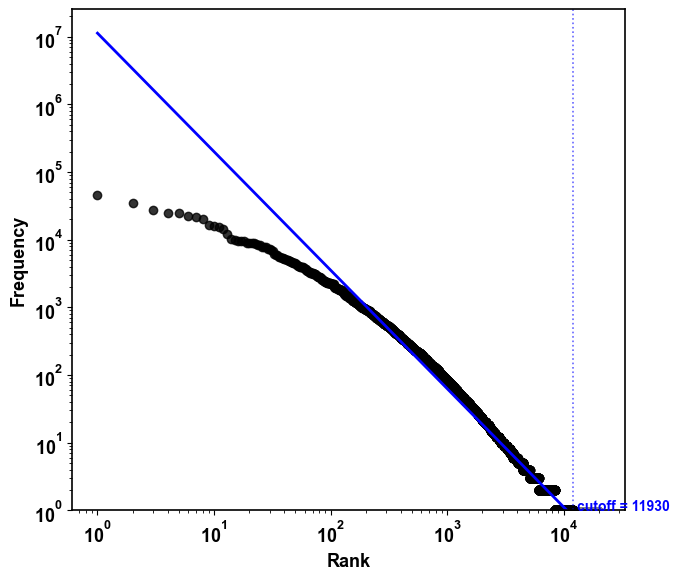

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)
    legend = ax.get_legend()
    if legend:
        legend.get_frame().set_edgecolor("black")

# ── Load Data ─────────────────────────────────────────────────────────────────
df_ing = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")
ing_counts  = df_ing['ing_id'].value_counts()
frequencies = ing_counts.values.astype(float)
ranks       = np.arange(1, len(frequencies) + 1)

log_ranks_all = np.log(ranks)
log_freqs_all = np.log(frequencies)

# ── R² scan (kept for diagnostic plot) ───────────────────────────────────────
MIN_HEAD = 10
STEP     = 10
candidate_ks = np.arange(MIN_HEAD, len(ranks) + 1, STEP)
r2_values    = []

for k in candidate_ks:
    lr = log_ranks_all[:k]
    lf = log_freqs_all[:k]
    slope, intercept_k = np.polyfit(lr, lf, 1)
    predicted = intercept_k + slope * lr
    ss_res = np.sum((lf - predicted) ** 2)
    ss_tot = np.sum((lf - lf.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 1.0
    r2_values.append(r2)

r2_values = np.array(r2_values)
r2_peak_k = int(candidate_ks[np.argmax(r2_values)])

# ── Cutoff = k at R² peak (most honest choice given the data shape) ───────────
# The R² curve has no sharp elbow — it is a broad hump peaking near k=12000.
# The peak of R² is the single k where the power-law OLS fit is globally best.
# We use this as the cutoff and report it transparently.
cutoff_rank = r2_peak_k

lr_fit = log_ranks_all[:cutoff_rank]
lf_fit = log_freqs_all[:cutoff_rank]
slope, intercept = np.polyfit(lr_fit, lf_fit, 1)
alpha = -slope

predicted_fit = intercept + slope * lr_fit
ss_res = np.sum((lf_fit - predicted_fit) ** 2)
ss_tot = np.sum((lf_fit - lf_fit.mean()) ** 2)
r2_at_cutoff = 1.0 - ss_res / ss_tot

print("-" * 55)
print(f"R² peak at k:                  {cutoff_rank}")
print(f"Cutoff used (R² peak):         rank = {cutoff_rank}")
print(f"α (power-law exponent):        {alpha:.4f}")
print(f"R² at cutoff:                  {r2_at_cutoff:.4f}")
print()
print("Note: No sharp elbow detected in R² curve.")
print("Cutoff set at R² peak — the k where OLS fit is best.")
print("-" * 55)

# ── Diagnostic: R² vs k ───────────────────────────────────────────────────────
fig_diag, ax_diag = plt.subplots(figsize=(7, 4))
ax_diag.plot(candidate_ks, r2_values, color='black', linewidth=1.2, label='R²')
ax_diag.axvline(cutoff_rank, color='blue', linestyle='--', linewidth=1.5,
                label=f'R² peak → cutoff = {cutoff_rank}')
ax_diag.scatter([cutoff_rank], [r2_values.max()],
                color='blue', zorder=5, s=40)
ax_diag.set_xlabel("Candidate cutoff (k)", fontweight="bold")
ax_diag.set_ylabel("R² (log–log OLS)", fontweight="bold")
ax_diag.set_title("Power-law regime: cutoff at R² peak", fontweight="bold")
format_axes(ax_diag)
ax_diag.legend(frameon=True)
plt.tight_layout()
plt.savefig("r2_cutoff_selection.png", dpi=300)
plt.savefig("r2_cutoff_selection.tif", dpi=300)
plt.show()

# ── Main Zipf Plot ─────────────────────────────────────────────────────────────
ranks_fit  = ranks[:cutoff_rank]
freqs_fit  = frequencies[:cutoff_rank]
ranks_tail = ranks[cutoff_rank:]
freqs_tail = frequencies[cutoff_rank:]

fig, ax = plt.subplots(figsize=(7, 6))

ax.loglog(ranks_tail, freqs_tail,
          marker='o', linestyle='none',
          alpha=0.2, color='gray', markersize=4, label='Tail')
ax.loglog(ranks_fit, freqs_fit,
          marker='o', linestyle='none',
          alpha=0.8, color='black', markersize=6, label='Empirical data (head)')

fit_x = np.linspace(1, cutoff_rank, 500)
fit_y = np.exp(intercept) * (fit_x ** -alpha)
ax.plot(fit_x, fit_y, color='blue', linestyle='-', linewidth=2,
        label=f'Power-law fit (α = {alpha:.2f})')

ax.axvline(cutoff_rank, color='blue', linestyle=':', linewidth=1.2, alpha=0.6)
ax.text(cutoff_rank * 1.1, freqs_fit[-1],
        f'cutoff = {cutoff_rank}', color='blue', fontsize=10)

ax.set_xlabel("Rank", fontweight="bold")
ax.set_ylabel("Frequency", fontweight="bold")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(bottom=1)
format_axes(ax)
plt.tight_layout()
plt.savefig("zipf_head_tail_best_fit.png", dpi=300)
plt.savefig("zipf_head_tail_best_fit.tif", dpi=300)
plt.show()

Total unique ingredients: 20280

--- Applying maximum likelihood estimation ---

Results from likelihood method:
  - Optimal cutoff (xmin):        3.0
  - Power law exponent (alpha):   1.5389
  - Standard error (sigma):       0.0069
  - Ingredients with freq >= xmin: 6088 / 20280 (30.0% of vocabulary)
  -> WARNING: alpha is estimated from only 30.0% of the vocabulary.
     The fit says nothing about the remaining 70.0% of ingredients (freq < xmin).

--- Performing hypothesis testing ---
Log-likelihood ratio (R): -4.9698
p-value: 0.0000

Interpretation (IMPORTANT — read carefully):
This is a RELATIVE test only: it compares power law vs lognormal
against EACH OTHER. It does NOT test whether either model is a good
absolute fit to the data. A 'win' for the power law here only means
'better than lognormal', not 'fits well'.
-> R=-4.970 < 0, p=0.0000 < 0.05: lognormal is SIGNIFICANTLY favored over power law.
   sigma (standard error on alpha) should be treated as UNRELIABLE under model missp

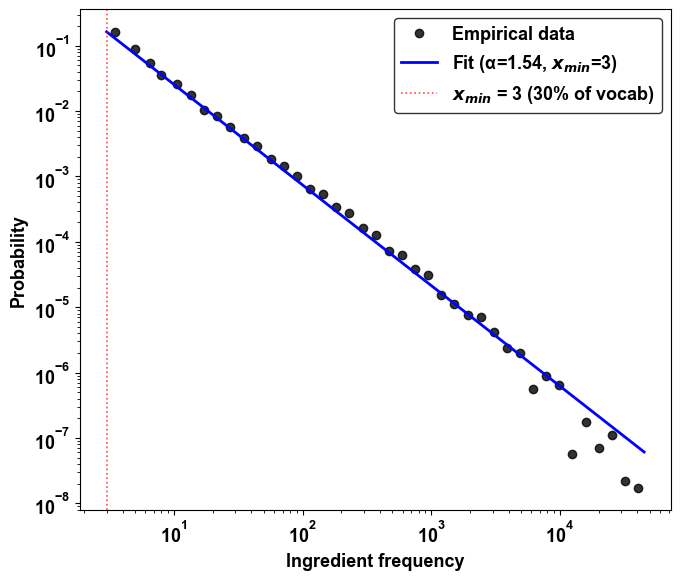

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13


def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")


# ==========================================
# 1. Load data
# ==========================================
df = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")

ing_counts = df['ing_id'].value_counts()
data = ing_counts.values

n_total = len(data)
print(f"Total unique ingredients: {n_total}")

# ==========================================
# 2. Fit model (MLE)
# ==========================================
print("\n--- Applying maximum likelihood estimation ---")

fit = powerlaw.Fit(data, discrete=True, verbose=False)

xmin  = fit.xmin
alpha = fit.alpha
sigma = fit.sigma

# How much of the vocabulary is actually covered by the fitted regime?
n_above_xmin = np.sum(data >= xmin)
frac_above_xmin = n_above_xmin / n_total

print("\nResults from likelihood method:")
print(f"  - Optimal cutoff (xmin):        {xmin}")
print(f"  - Power law exponent (alpha):   {alpha:.4f}")
print(f"  - Standard error (sigma):       {sigma:.4f}")
print(f"  - Ingredients with freq >= xmin: {n_above_xmin} / {n_total} "
      f"({frac_above_xmin*100:.1f}% of vocabulary)")

if frac_above_xmin < 0.5:
    print(f"  -> WARNING: alpha is estimated from only {frac_above_xmin*100:.1f}% "
          f"of the vocabulary.")
    print(f"     The fit says nothing about the remaining "
          f"{(1-frac_above_xmin)*100:.1f}% of ingredients (freq < xmin).")

# ==========================================
# 3. Hypothesis testing (relative comparison only)
# ==========================================
print("\n--- Performing hypothesis testing ---")

R, p = fit.distribution_compare('power_law', 'lognormal', normalized_ratio=True)

print(f"Log-likelihood ratio (R): {R:.4f}")
print(f"p-value: {p:.4f}")

print("\nInterpretation (IMPORTANT — read carefully):")
print("This is a RELATIVE test only: it compares power law vs lognormal")
print("against EACH OTHER. It does NOT test whether either model is a good")
print("absolute fit to the data. A 'win' for the power law here only means")
print("'better than lognormal', not 'fits well'.")

if p < 0.05:
    if R > 0:
        print(f"-> R={R:.3f} > 0, p={p:.4f} < 0.05: power law is "
              f"SIGNIFICANTLY favored over lognormal.")
    else:
        print(f"-> R={R:.3f} < 0, p={p:.4f} < 0.05: lognormal is "
              f"SIGNIFICANTLY favored over power law.")
        print("   sigma (standard error on alpha) should be treated as "
              "UNRELIABLE under model misspecification.")
else:
    print(f"-> p={p:.4f} >= 0.05: the test CANNOT distinguish between power "
          f"law and lognormal for this data.")
    print("   Neither model is preferred; do not claim power-law behavior "
          "based on this comparison alone.")

# ==========================================
# Absolute goodness-of-fit, via manual KS distance
# ==========================================
# fit.power_law.KS() is broken in some powerlaw package versions
# (calls an internal helper that isn't properly imported).
# Compute the KS distance manually instead.

sorted_data = np.sort(data[data >= xmin])
n = len(sorted_data)

# Empirical CDF
empirical_cdf = np.arange(1, n + 1) / n

# Theoretical power-law CDF at the same data points
theoretical_cdf = fit.power_law.cdf(sorted_data)

ks_stat = np.max(np.abs(empirical_cdf - theoretical_cdf))

print(f"\nAbsolute fit quality of the power law itself:")
print(f"  - KS distance (empirical vs fitted power law): {ks_stat:.4f}")
print("    (Lower is better; this is NOT a p-value. There is no universal")
print("     cutoff for 'good' KS — report it alongside R, p, and the")
print("     vocabulary-coverage fraction above as a package of evidence.)")
print("    (Lower is better; this is NOT a p-value. There is no universal")
print("     cutoff for 'good' KS — report it alongside R, p, and the")
print("     vocabulary-coverage fraction above as a package of evidence.)")

# ==========================================
# 4. Rank-frequency exponent: beta = 1/(alpha - 1), with caveats
# ==========================================
print("\n--- Converting alpha to rank-frequency exponent (beta) ---")

beta = 1.0 / (alpha - 1.0)

# Propagate uncertainty in alpha into beta via the delta method:
# d(beta)/d(alpha) = -1 / (alpha - 1)^2
beta_sigma = sigma / (alpha - 1.0) ** 2

print(f"  - alpha:                      {alpha:.4f} +/- {sigma:.4f}")
print(f"  - beta = 1/(alpha-1):         {beta:.4f} +/- {beta_sigma:.4f} "
      f"(propagated via delta method)")
print("\nCaveats on this conversion (do not skip in your report):")
print("  1. beta = 1/(alpha-1) is an asymptotic result for a PURE Pareto")
print("     distribution with NO lower cutoff. Here the fit is truncated")
print(f"     at xmin={xmin}, covering only {frac_above_xmin*100:.1f}% of the data.")
print("  2. It assumes the sample is large enough that rank ~ order statistic")
print("     of the Pareto distribution. Finite-sample deviations are not")
print("     quantified here.")
print("  3. beta_sigma above only propagates the Fisher-information error on")
print("     alpha — it does NOT account for the truncation or for model")
print("     misspecification (relevant if R < 0 above). Treat beta as an")
print("     approximation with unknown additional error, not a precise value.")

# ==========================================
# 5. Plot
# ==========================================
fig, ax = plt.subplots(figsize=(7, 6))

# Empirical data (full, including points below xmin, shown for context)
fit.plot_pdf(
    color='black',
    linestyle='none',
    marker='o',
    alpha=0.8,
    markersize=6,
    label='Empirical data',
    ax=ax
)

# Fitted power-law PDF, drawn by the library itself.
# This uses powerlaw's own binning/normalization, so it is consistent with
# fit.plot_pdf's empirical curve, and it is only drawn for x >= xmin —
# no extrapolation below the fitted regime.
fit.power_law.plot_pdf(
    color='blue',
    linestyle='-',
    linewidth=2,
    label=rf'Fit (α={alpha:.2f}, $x_{{min}}$={xmin:.0f})',
    ax=ax
)

# Mark xmin explicitly so the reader sees where the fitted regime begins
ax.axvline(xmin, color='red', linestyle=':', linewidth=1.2, alpha=0.7,
           label=f'$x_{{min}}$ = {xmin:.0f} '
                 f'({frac_above_xmin*100:.0f}% of vocab)')

ax.set_xlabel("Ingredient frequency", fontweight="bold")
ax.set_ylabel("Probability", fontweight="bold")

ax.set_xscale("log")
ax.set_yscale("log")

format_axes(ax)

plt.tight_layout()

# Save figures
plt.savefig("zipf_likelihood_method_fit.png", dpi=300)
plt.savefig("zipf_likelihood_method_fit.tif", dpi=300)

plt.show()

Loading data...

--- Processing Heaps' law (rigorous fit) ---
Running 10 simulations to generate stable growth curve...
--------------------------------------------------
Heaps law parameters (best fit, linear-space, std-weighted):
  Constant (K):  26.8400
  Exponent (β):  0.567391 +/- 0.000016  (1 std error)
  Burn-in used:  first 50 recipes excluded from fit
--------------------------------------------------
Model comparison (AIC, all fit in linear space):
  Heaps law (power, concave):   1078678.93
  Logarithmic (concave):        1874502.21
  Linear (NOT concave):         1639389.40

Note: V(R) is structurally concave (finite ingredient vocabulary,
~19,000 max), so the linear model is a weak baseline almost any
concave model will beat. The Heaps-vs-log comparison above is the
more informative test of whether growth is specifically power-law
shaped, rather than just 'any concave curve'.
Result: Evidence favors Heaps' (power-law) growth specifically.
-----------------------------------

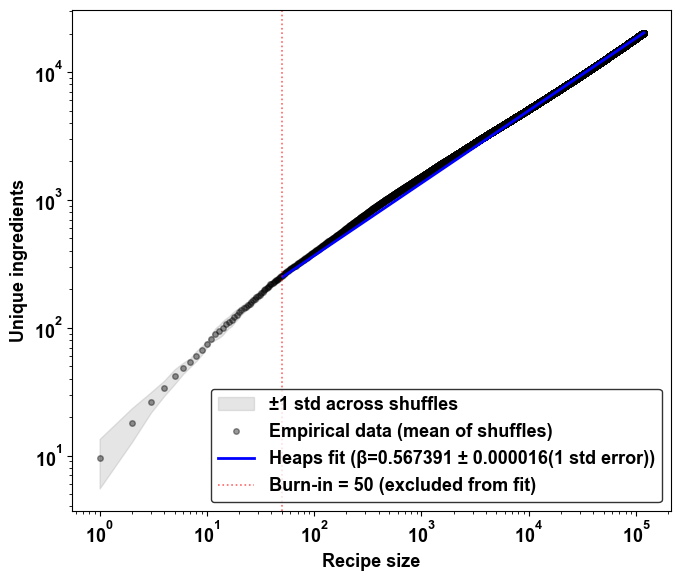


Caveat: the fit (curve_fit on K*x^beta) was performed in LINEAR
space, weighting absolute residuals — large-x points dominate the
loss. The plot above uses log-log axes (the field convention for
Heaps' law), which can visually flatter the fit, especially at
small x, where the linear-space optimizer barely penalised error.
If you need a fit that matches proportionally well across all
scales (not just large recipe counts), fit on log-transformed data
instead, as was done in the earlier Heaps' law cell.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13


def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True, loc='lower right')
    if legend:
        legend.get_frame().set_edgecolor("black")


# ==========================================
# 1. Load data
# ==========================================
print("Loading data...")
df = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")

# ==========================================
# 2. Simulate vocabulary growth (with per-shuffle curves retained)
# ==========================================
print("\n--- Processing Heaps' law (rigorous fit) ---")

recipe_groups = df.groupby('recipe_no')['ing_id'].apply(set).tolist()
n_recipes = len(recipe_groups)

num_simulations = 10
v_history = np.zeros((num_simulations, n_recipes))

print(f"Running {num_simulations} simulations to generate stable growth curve...")

for i in range(num_simulations):
    shuffled = np.random.permutation(np.array(recipe_groups, dtype=object))
    unique_set = set()
    current_v = []
    for r in shuffled:
        unique_set.update(r)
        current_v.append(len(unique_set))
    v_history[i, :] = current_v

y_mean = np.mean(v_history, axis=0)
y_std  = np.std(v_history, axis=0)
x_data = np.arange(1, n_recipes + 1)

# ==========================================
# 3. Define models — including a second concave alternative
# ==========================================
# Vocabulary growth V(R) is structurally concave: the ingredient space is
# finite (~19,000 unique ingredients possible), so growth MUST flatten as R
# grows. Comparing Heaps' law only against a straight line is not a neutral
# test — a straight line cannot flatten, so almost any concave model will
# beat it by construction. Adding a logarithmic model gives a fairer,
# concave-vs-concave comparison.

def heaps_model(x, K, beta):
    return K * (x ** beta)

def linear_model(x, m, c):
    return m * x + c

def log_model(x, a, b):
    return a * np.log(x) + b

# ==========================================
# 4. Fit models — burn-in applied, std-weighted fit, pcov retained
# ==========================================
# burn_in excludes the earliest, most volatile region of V(R), where a
# handful of recipes can introduce a large fraction of their ingredients at
# once. Including this region (burn_in=0) can bias beta, especially for a
# linear-space fit where large-V points already dominate the loss.
burn_in = 50

x_fit = x_data[burn_in:]
y_fit = y_mean[burn_in:]
y_fit_std = y_std[burn_in:]

# Avoid zero-division in weighted fit if any std is 0 (possible at very
# start of curve before burn-in, or if all shuffles agree exactly)
sigma_for_fit = np.where(y_fit_std > 0, y_fit_std, np.nanmean(y_fit_std[y_fit_std > 0]))

# sigma= and absolute_sigma=True make curve_fit account for the
# across-shuffle variance at each point, instead of treating the single mean
# curve as if it were noiseless. pcov is now kept (not discarded with _),
# so we can report standard errors on every fitted parameter.
popt_heaps, pcov_heaps = curve_fit(
    heaps_model, x_fit, y_fit, p0=[10, 0.5],
    sigma=sigma_for_fit, absolute_sigma=True
)
popt_lin, pcov_lin = curve_fit(
    linear_model, x_fit, y_fit, p0=[1, 0],
    sigma=sigma_for_fit, absolute_sigma=True
)
popt_log, pcov_log = curve_fit(
    log_model, x_fit, y_fit, p0=[1000, 0],
    sigma=sigma_for_fit, absolute_sigma=True
)

beta_se = np.sqrt(pcov_heaps[1, 1])

# ==========================================
# 5. Model comparison (AIC) — three models, same linear-space residuals
# ==========================================
def calculate_aic(y_true, y_pred, num_params):
    rss = np.sum((y_true - y_pred) ** 2)
    n = len(y_true)
    return n * np.log(rss / n) + 2 * num_params

y_pred_heaps = heaps_model(x_fit, *popt_heaps)
aic_heaps = calculate_aic(y_fit, y_pred_heaps, num_params=2)

y_pred_lin = linear_model(x_fit, *popt_lin)
aic_lin = calculate_aic(y_fit, y_pred_lin, num_params=2)

y_pred_log = log_model(x_fit, *popt_log)
aic_log = calculate_aic(y_fit, y_pred_log, num_params=2)

print("-" * 50)
print("Heaps law parameters (best fit, linear-space, std-weighted):")
print(f"  Constant (K):  {popt_heaps[0]:.4f}")
print(f"  Exponent (β):  {popt_heaps[1]:.6f} +/- {beta_se:.6f}  (1 std error)")
print(f"  Burn-in used:  first {burn_in} recipes excluded from fit")
print("-" * 50)

print("Model comparison (AIC, all fit in linear space):")
print(f"  Heaps law (power, concave):   {aic_heaps:.2f}")
print(f"  Logarithmic (concave):        {aic_log:.2f}")
print(f"  Linear (NOT concave):         {aic_lin:.2f}")
print()
print("Note: V(R) is structurally concave (finite ingredient vocabulary,")
print("~19,000 max), so the linear model is a weak baseline almost any")
print("concave model will beat. The Heaps-vs-log comparison above is the")
print("more informative test of whether growth is specifically power-law")
print("shaped, rather than just 'any concave curve'.")

best_aic = min(aic_heaps, aic_log, aic_lin)
if best_aic == aic_heaps:
    print("Result: Evidence favors Heaps' (power-law) growth specifically.")
elif best_aic == aic_log:
    print("Result: Evidence favors logarithmic growth over Heaps' power law.")
else:
    print("Result: Evidence favors linear growth (unexpected given finite vocabulary).")
print("-" * 50)

# ==========================================
# 6. Plot — fit and display in the SAME (linear) space, log-log shown
#    only as a secondary visual reference with explicit caveat
# ==========================================
# IMPORTANT: this fit was performed in linear space (curve_fit on raw
# K*x^beta), not log-log OLS. Plotting on log-log axes is the conventional
# way to display Heaps' law and makes power laws look like straight lines,
# but it can create a visual impression of fit quality that doesn't match
# what was actually optimised (linear-space squared error, which barely
# penalises small-x deviations). We keep the log-log display since it's
# the field convention, but state this mismatch explicitly so it isn't
# silently misleading.

fig, ax = plt.subplots(figsize=(7, 6))

# Shuffle variability shown as a shaded band, not discarded
ax.fill_between(
    x_data, y_mean - y_std, y_mean + y_std,
    color='gray', alpha=0.2, label='±1 std across shuffles'
)

ax.plot(
    x_data, y_mean,
    marker='o', linestyle='none', color='black',
    markersize=4, alpha=0.4, label='Empirical data (mean of shuffles)'
)

ax.plot(
    x_fit, y_pred_heaps,
    color='blue', linestyle='-', linewidth=2,
    label=f'Heaps fit (β={popt_heaps[1]:.6f} ± {beta_se:.6f})'
)

ax.axvline(burn_in, color='red', linestyle=':', linewidth=1.2, alpha=0.6,
           label=f'Burn-in = {burn_in} (excluded from fit)')

ax.set_xlabel("Recipe size", fontweight="bold")
ax.set_ylabel("Unique ingredients", fontweight="bold")

ax.set_xscale('log')
ax.set_yscale('log')

format_axes(ax)

plt.tight_layout()
plt.savefig("heaps_law_rigorous_fit.png", dpi=300)
plt.savefig("heaps_law_rigorous_fit.tif", dpi=300)
plt.show()

print("\nCaveat: the fit (curve_fit on K*x^beta) was performed in LINEAR")
print("space, weighting absolute residuals — large-x points dominate the")
print("loss. The plot above uses log-log axes (the field convention for")
print("Heaps' law), which can visually flatter the fit, especially at")
print("small x, where the linear-space optimizer barely penalised error.")
print("If you need a fit that matches proportionally well across all")
print("scales (not just large recipe counts), fit on log-transformed data")
print("instead, as was done in the earlier Heaps' law cell.")


--- Processing Menzerath-Altmann (Likelihood method) ---
Bins retained after stability filter (n>=10 recipes): 30
  Recipes per bin: min=10, median=1809, max=12396
Note: bins are NOT weighted equally below — each is weighted by its
standard error of the mean (std/sqrt(n)), so bins built from more
recipes or with lower internal spread have proportionally more
influence on the fit than thinly-supported bins.
-------------------------------------------------------
Maximum likelihood estimation results:
  Full MA model LL:   53.9159
  Power law model LL: 12.1423
-------------------------------------------------------
Parameter estimates with standard errors (from pcov):
  Full MA model:  A=13.0003 +/- 0.0699, b=-0.2615 +/- 0.0039, c=-0.02046 +/- 0.00035
  Power model:    A=9.8356 +/- 0.0253, b=-0.0456 +/- 0.0011
-------------------------------------------------------
Goodness of fit (R^2, for comparison with literature values):
  Full MA model R^2:  0.9215
  Power model R^2:    -0.2711
  

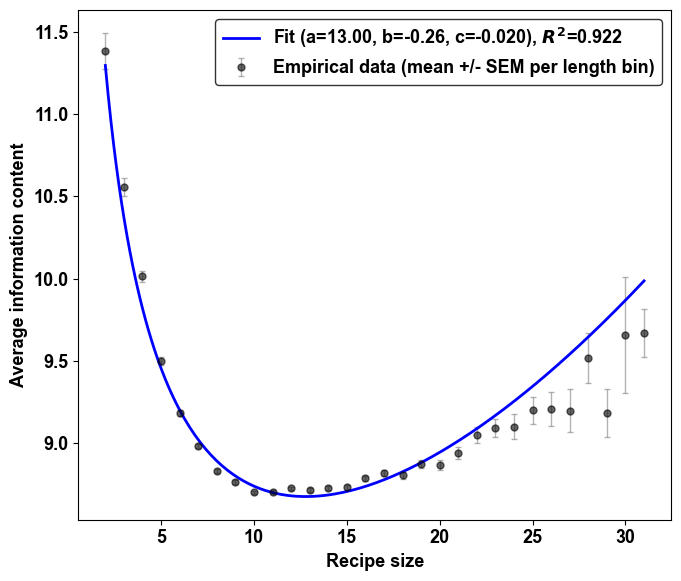

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13


def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")


# ==========================================
# Load data
# ==========================================
df = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")

print("\n--- Processing Menzerath-Altmann (Likelihood method) ---")

# Calculate information content
ing_counts = df['ing_id'].value_counts()
probs = ing_counts / len(df)

df['ic'] = -np.log2(df['ing_id'].map(probs))

# Group by recipe
groups = df.groupby('recipe_no')

recipe_lengths = groups.size()
recipe_mean_ic = groups['ic'].mean()

# Mean-field averaging
ma_data = pd.DataFrame({
    'Length': recipe_lengths,
    'Mean_IC': recipe_mean_ic
})

# ==========================================
# Bin aggregation — now retains count AND std per length bin
# ==========================================
# Unweighted aggregation problem: groupby('Length').mean() treats a length
# bin backed by 10,000 recipes identically to one backed by 10 recipes (the
# minimum allowed by the stability filter below). Both contribute one point
# of equal weight to the fit, even though the 10,000-recipe bin's mean is
# far more reliable. We now also compute the std and count per bin, so this
# can be used to weight the fit and to report a measure of bin reliability.
ma_agg = ma_data.groupby('Length')['Mean_IC'].agg(['mean', 'std', 'count']).reset_index()
ma_agg.columns = ['Length', 'Mean_IC', 'Std_IC', 'N_recipes']

# Stability filtering — kept as before (minimum 10 recipes per length bin)
valid_counts = ma_data['Length'].value_counts()
valid_lengths = valid_counts[valid_counts >= 10].index

ma_grouped = ma_agg[ma_agg['Length'].isin(valid_lengths)].sort_values('Length')

x_data = ma_grouped['Length'].values
y_data = ma_grouped['Mean_IC'].values
y_std  = ma_grouped['Std_IC'].values
n_per_bin = ma_grouped['N_recipes'].values

n_samples = len(y_data)

# Standard error of the mean per bin, used as fit weight.
# Bins with more recipes (n_per_bin large) and/or lower internal variance
# (y_std small) get a smaller SEM, i.e. more trust in the fit below.
# Guard against std=0 (can happen if every recipe of that length has
# identical Mean_IC, e.g. very small bins right at the n>=10 cutoff).
sem_per_bin = np.where(
    y_std > 0,
    y_std / np.sqrt(n_per_bin),
    np.nanmean(y_std[y_std > 0]) / np.sqrt(n_per_bin)
)

print(f"Bins retained after stability filter (n>=10 recipes): {n_samples}")
print(f"  Recipes per bin: min={n_per_bin.min()}, median={int(np.median(n_per_bin))}, "
      f"max={n_per_bin.max()}")
print("Note: bins are NOT weighted equally below — each is weighted by its")
print("standard error of the mean (std/sqrt(n)), so bins built from more")
print("recipes or with lower internal spread have proportionally more")
print("influence on the fit than thinly-supported bins.")


# ==========================================
# Models
# ==========================================
def ma_model(x, A, b, c):
    return A * (x ** b) * np.exp(-c * x)

def power_model(x, A, b):
    return A * (x ** b)


# ==========================================
# Fitting — pcov retained, weighted by SEM
# ==========================================
try:
    popt_ma, pcov_ma = curve_fit(
        ma_model,
        x_data,
        y_data,
        p0=[10, -0.1, 0.01],
        sigma=sem_per_bin,
        absolute_sigma=True,
        maxfev=10000
    )

    perr_ma = np.sqrt(np.diag(pcov_ma))  # standard errors on A, b, c

    y_pred_ma = ma_model(x_data, *popt_ma)
    rss_ma = np.sum((y_data - y_pred_ma) ** 2)

    # R^2 for the full MA model
    ss_tot = np.sum((y_data - y_data.mean()) ** 2)
    r2_ma = 1.0 - rss_ma / ss_tot if ss_tot > 0 else np.nan

    fit_success = True

except Exception as e:
    fit_success = False
    print(f"MA model fit failed: {e}")


try:
    popt_pow, pcov_pow = curve_fit(
        power_model,
        x_data,
        y_data,
        p0=[10, -0.1],
        sigma=sem_per_bin,
        absolute_sigma=True,
        maxfev=10000
    )

    perr_pow = np.sqrt(np.diag(pcov_pow))  # standard errors on A, b

    y_pred_pow = power_model(x_data, *popt_pow)
    rss_pow = np.sum((y_data - y_pred_pow) ** 2)

    ss_tot = np.sum((y_data - y_data.mean()) ** 2)
    r2_pow = 1.0 - rss_pow / ss_tot if ss_tot > 0 else np.nan

except Exception as e:
    fit_success = False
    print(f"Power model fit failed: {e}")


# ==========================================
# Likelihood test
# ==========================================
if fit_success:

    ll_ma = -0.5 * n_samples * np.log(rss_ma / n_samples)
    ll_pow = -0.5 * n_samples * np.log(rss_pow / n_samples)

    D = -2 * (ll_pow - ll_ma)

    p_value = chi2.sf(D, df=1)

    print("-" * 55)
    print("Maximum likelihood estimation results:")
    print(f"  Full MA model LL:   {ll_ma:.4f}")
    print(f"  Power law model LL: {ll_pow:.4f}")
    print("-" * 55)

    print("Parameter estimates with standard errors (from pcov):")
    print(f"  Full MA model:  A={popt_ma[0]:.4f} +/- {perr_ma[0]:.4f}, "
          f"b={popt_ma[1]:.4f} +/- {perr_ma[1]:.4f}, "
          f"c={popt_ma[2]:.5f} +/- {perr_ma[2]:.5f}")
    print(f"  Power model:    A={popt_pow[0]:.4f} +/- {perr_pow[0]:.4f}, "
          f"b={popt_pow[1]:.4f} +/- {perr_pow[1]:.4f}")
    print("-" * 55)

    print("Goodness of fit (R^2, for comparison with literature values):")
    print(f"  Full MA model R^2:  {r2_ma:.4f}")
    print(f"  Power model R^2:    {r2_pow:.4f}")
    print("  (The original Menzerath-Altmann literature commonly reports")
    print("   R^2 around 0.99 for the full model on similar text/corpus data;")
    print("   compare against that benchmark directly here rather than")
    print("   relying on the LRT result alone.)")
    print("-" * 55)

    print("Likelihood ratio test:")
    print(f"  Statistic D: {D:.4f}")
    print(f"  p value: {p_value:.6f}")

    if p_value < 0.05:

        print("Result: Evidence favors full Menzerath-Altmann law (c != 0 "
              "is statistically supported).")

        best_model_label = (f'Fit (a={popt_ma[0]:.2f}, b={popt_ma[1]:.2f}, '
                             f'c={popt_ma[2]:.3f}), $R^2$={r2_ma:.3f}')
        model_func = ma_model
        model_params = popt_ma

    else:

        print("Result: Evidence favors simple power law (c=0 cannot be "
              "rejected).")

        best_model_label = (f'Fit (a={popt_pow[0]:.2f}, b={popt_pow[1]:.2f}), '
                             f'$R^2$={r2_pow:.3f}')
        model_func = power_model
        model_params = popt_pow

    print("-" * 55)
    print("Caveat: bins were aggregated as group means of Mean_IC, which is")
    print("the same averaging procedure used throughout — wide-support bins")
    print("(many recipes) and thin-support bins (as few as 10 recipes, the")
    print("filter minimum) are now weighted differently in the FIT via SEM,")
    print("but the y_data point shown on the plot below is still a simple")
    print("group mean either way. The LRT and R^2 above are computed on")
    print("these SEM-weighted residuals, not on raw unweighted means.")

    # ==========================================
    # Plot
    # ==========================================
    fig, ax = plt.subplots(figsize=(7, 6))

    # Empirical data, with marker size or error bars reflecting bin reliability
    ax.errorbar(
        x_data, y_data, yerr=sem_per_bin,
        fmt='o', color='black', alpha=0.6, markersize=5,
        ecolor='gray', elinewidth=1, capsize=2,
        label='Empirical data (mean +/- SEM per length bin)'
    )

    # Fit
    x_line = np.linspace(x_data.min(), x_data.max(), 200)
    y_line = model_func(x_line, *model_params)

    ax.plot(
        x_line,
        y_line,
        color='blue',
        linewidth=2,
        label=best_model_label
    )

    ax.set_xlabel("Recipe size", fontweight="bold")
    ax.set_ylabel("Average information content", fontweight="bold")

    format_axes(ax)

    plt.tight_layout()

    plt.savefig("menzerath_altmann_likelihood_test.png", dpi=300)
    plt.savefig("menzerath_altmann_likelihood_test.tif", dpi=300)

    plt.show()

else:
    print("Optimization failed.")

In [19]:
!pip install powerlaw

import pandas as pd
import numpy as np
import powerlaw

# ==========================================
# 1. LOAD DATA
# ==========================================
print("Loading data...")
df = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")

# Get Frequency Data
ing_counts = df['ing_id'].value_counts()
data = ing_counts.values

# ==========================================
# 2. CALCULATE ALPHA & CONFIDENCE
# ==========================================
print("\n--- Calculates Zipf's Law Parameters ---")

fit = powerlaw.Fit(data, discrete=True, verbose=False)

alpha = fit.alpha
sigma = fit.sigma
xmin = fit.xmin

# 95% Confidence Interval on alpha
ci_lower = alpha - (1.96 * sigma)
ci_upper = alpha + (1.96 * sigma)

# ==========================================
# 2b. Model-correctness check — does the CI on alpha even mean anything?
# ==========================================
# The CI above (alpha +/- 1.96*sigma) is the sampling uncertainty UNDER THE
# ASSUMPTION that the data is truly drawn from a discrete power law with this
# xmin. It says nothing about how wrong alpha could be if the real
# distribution is actually a truncated power law or lognormal instead — it
# is conditional on the Pareto model being correct. We check that assumption
# here using the same relative comparison as the earlier MLE cell, so this
# CI is not reported in a vacuum.
R, p = fit.distribution_compare('power_law', 'lognormal', normalized_ratio=True)

print("Model-correctness check (power law vs lognormal):")
print(f"  R = {R:.4f}, p = {p:.4f}")
if p < 0.05 and R < 0:
    print("  -> Lognormal is SIGNIFICANTLY favored over power law.")
    print("     The CI on alpha below assumes Pareto correctness, which this")
    print("     test contradicts. Treat the CI as reporting PRECISION,")
    print("     not ACCURACY — alpha could be precisely estimated for the")
    print("     wrong model.")
elif p < 0.05 and R > 0:
    print("  -> Power law is significantly favored over lognormal.")
    print("     The CI on alpha is on firmer footing, though this still does")
    print("     not rule out other alternative distributions entirely.")
else:
    print("  -> Comparison is inconclusive (p >= 0.05).")
    print("     Neither model is preferred; the CI on alpha should be")
    print("     reported with this ambiguity noted.")

# Rank-frequency slope, WITH propagated uncertainty (delta method)
beta = 1.0 / (alpha - 1.0)
sigma_beta = sigma / (alpha - 1.0) ** 2
beta_ci_lower = beta - (1.96 * sigma_beta)
beta_ci_upper = beta + (1.96 * sigma_beta)

# ==========================================
# 3. PRINT RESULTS
# ==========================================
print("-" * 50)
print(f"RESULTS FOR LIKELIHOOD FIT (xmin={xmin})")
print("-" * 50)
print(f"Alpha (Distribution Exponent):  {alpha:.6f}")
print(f"Standard Error (Sigma):         {sigma:.6f}")
print(f"95% CI on Alpha:                [{ci_lower:.6f}, {ci_upper:.6f}]")
print(f"  (conditional on Pareto model correctness — see check above)")
print()
print(f"Beta (Zipf Rank Slope):         {beta:.6f}")
print(f"Propagated Sigma on Beta:       {sigma_beta:.6f}  (delta method)")
print(f"95% CI on Beta:                 [{beta_ci_lower:.6f}, {beta_ci_upper:.6f}]")
print(f"  (compare against literature value beta ~ 0.54-0.56 using this")
print(f"   interval, not the bare point estimate)")
print("-" * 50)

# ==========================================
# 4. EXPORT RESULTS TO CSV
# ==========================================
results = pd.DataFrame({
    "xmin": [xmin],
    "alpha": [alpha],
    "sigma_alpha": [sigma],
    "alpha_ci_lower": [ci_lower],
    "alpha_ci_upper": [ci_upper],
    "R_powerlaw_vs_lognormal": [R],
    "p_powerlaw_vs_lognormal": [p],
    "beta": [beta],
    "sigma_beta": [sigma_beta],
    "beta_ci_lower": [beta_ci_lower],
    "beta_ci_upper": [beta_ci_upper]
})

results.to_csv("zipf_law_parameters.csv", index=False)

print("Results exported to zipf_law_parameters.csv")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Loading data...

--- Calculates Zipf's Law Parameters ---
Model-correctness check (power law vs lognormal):
  R = -4.9698, p = 0.0000
  -> Lognormal is SIGNIFICANTLY favored over power law.
     The CI on alpha below assumes Pareto correctness, which this
     test contradicts. Treat the CI as reporting PRECISION,
     not ACCURACY — alpha could be precisely estimated for the
     wrong model.
--------------------------------------------------
RESULTS FOR LIKELIHOOD FIT (xmin=3.0)
--------------------------------------------------
Alpha (Distribution Exponent):  1.538921
Standard Error (Sigma):         0.006907
95% CI on Alpha:                [1.525383, 1.552459]
  (conditional on Pareto model correctness — see check above)

Beta (Zipf Rank Slope):         1.855560
Propagated Sigma on Beta:       0.023781  (delta method)
95% CI on Beta:                 [1.808948, 1.902172]
  (compare against literature value 

Loading data...

--- Fitting distributions ---
Optimal cutoff (xmin): 3.0


C:\Users\Parth\AppData\Roaming\Python\Python314\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
C:\Users\Parth\AppData\Roaming\Python\Python314\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



--- Model comparison ---
Power law vs Lognormal:            R=-4.9698, p=0.0000 -> Lognormal
Power law vs Exponential:          R=22.3691, p=0.0000 -> Power law
Power law vs Truncated power law:  R=-7.9181, p=0.0000 -> Truncated power law

Interpretation notes:
  - Power law vs Exponential tests whether a heavy tail exists at
    all. These two distributions differ sharply in tail behavior, so
    this comparison is expected to be decisive (large |R|, small p).
    A win here only confirms 'heavy tail present' — it says nothing
    about whether that tail is power-law-shaped specifically.
  - Power law vs Lognormal is the harder, more informative test:
    lognormal can closely mimic a power law over a finite range
    (Clauset et al. 2009), so 'Inconclusive' here is a common and
    legitimate result, not a failure of the test.
  - Power law vs Truncated power law is the most relevant comparison
    for THIS dataset specifically: ingredient frequency has a hard
    upper bound (an in

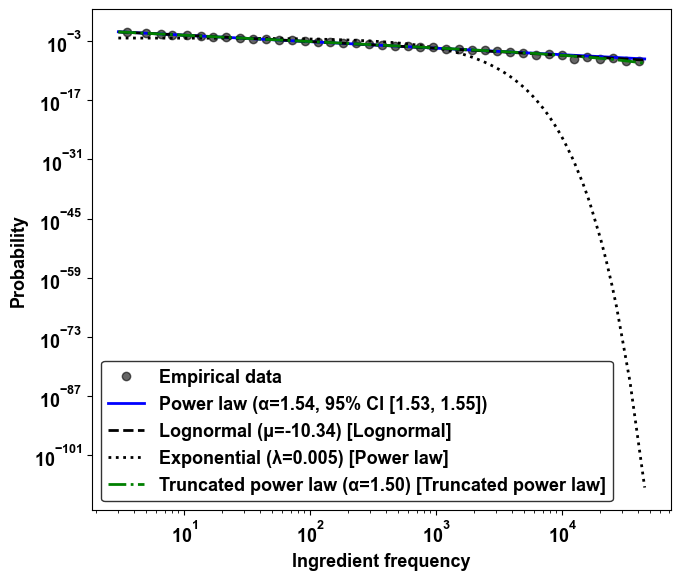

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13


def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")


# ==========================================
# 1. Load data
# ==========================================
print("Loading data...")
df = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")

ing_counts = df['ing_id'].value_counts()
data = ing_counts.values


# ==========================================
# 2. Fit models (MLE) — now including truncated power law
# ==========================================
print("\n--- Fitting distributions ---")

fit = powerlaw.Fit(data, discrete=True, verbose=False)
xmin = fit.xmin

print(f"Optimal cutoff (xmin): {xmin}")

# Power law
alpha = fit.power_law.alpha
sigma = fit.power_law.sigma

# 95% CI on alpha — built here too, so this cell is consistent with Cell 7
# rather than leaving sigma sitting unused.
alpha_ci_lower = alpha - (1.96 * sigma)
alpha_ci_upper = alpha + (1.96 * sigma)

# Lognormal — NOTE: mu/sigma here describe the ingredient FREQUENCY-COUNT
# distribution, not the macronutrient-concentration lognormal from the
# original paper. Do not compare these two mu/sigma pairs directly anywhere
# downstream — they are different quantities in different units.
mu = fit.lognormal.mu
sigma_log = fit.lognormal.sigma

# Exponential — lamb is the decay rate in (1/frequency-count) units,
# estimated over the same x >= xmin range as the power law. Report units if
# this is reused anywhere as an "ingredient usage decay rate."
lamb = fit.exponential.parameter1

# Truncated power law — theoretically more appropriate than the unbounded
# Pareto here, since ingredient frequency has a hard upper bound (an
# ingredient cannot appear in more recipes than exist in the corpus).
tpl_alpha = fit.truncated_power_law.parameter1
tpl_lambda = fit.truncated_power_law.parameter2


# ==========================================
# 3. Model comparison — three-way outcome, not sign-of-R alone
# ==========================================
print("\n--- Model comparison ---")

R_pl_ln, p_pl_ln = fit.distribution_compare(
    'power_law', 'lognormal', normalized_ratio=True)

R_pl_ex, p_pl_ex = fit.distribution_compare(
    'power_law', 'exponential', normalized_ratio=True)

R_pl_tpl, p_pl_tpl = fit.distribution_compare(
    'power_law', 'truncated_power_law', normalized_ratio=True)


def classify_winner(R, p, name_a, name_b, alpha_level=0.05):
    """
    Three-way outcome instead of picking a winner from sign(R) alone.
    If p >= alpha_level, the comparison is statistically inconclusive —
    the test cannot distinguish the two models, and reporting a 'winner'
    in that case would be misleading (e.g. R=0.001, p=0.97 should NOT be
    logged as a win for either model).
    """
    if p >= alpha_level:
        return "Inconclusive"
    return name_a if R > 0 else name_b


winner_ln  = classify_winner(R_pl_ln,  p_pl_ln,  "Power law", "Lognormal")
winner_ex  = classify_winner(R_pl_ex,  p_pl_ex,  "Power law", "Exponential")
winner_tpl = classify_winner(R_pl_tpl, p_pl_tpl, "Power law", "Truncated power law")

print(f"Power law vs Lognormal:            R={R_pl_ln:.4f}, p={p_pl_ln:.4f} -> {winner_ln}")
print(f"Power law vs Exponential:          R={R_pl_ex:.4f}, p={p_pl_ex:.4f} -> {winner_ex}")
print(f"Power law vs Truncated power law:  R={R_pl_tpl:.4f}, p={p_pl_tpl:.4f} -> {winner_tpl}")

print()
print("Interpretation notes:")
print("  - Power law vs Exponential tests whether a heavy tail exists at")
print("    all. These two distributions differ sharply in tail behavior, so")
print("    this comparison is expected to be decisive (large |R|, small p).")
print("    A win here only confirms 'heavy tail present' — it says nothing")
print("    about whether that tail is power-law-shaped specifically.")
print("  - Power law vs Lognormal is the harder, more informative test:")
print("    lognormal can closely mimic a power law over a finite range")
print("    (Clauset et al. 2009), so 'Inconclusive' here is a common and")
print("    legitimate result, not a failure of the test.")
print("  - Power law vs Truncated power law is the most relevant comparison")
print("    for THIS dataset specifically: ingredient frequency has a hard")
print("    upper bound (an ingredient cannot appear in more recipes than")
print("    exist in the corpus), so the truncated model is theoretically")
print("    the more appropriate heavy-tailed candidate, not the unbounded")
print("    Pareto. If truncated power law wins here, the 'pure' alpha")
print("    reported above should be read as an approximation to a")
print("    bounded process, not a literal unbounded tail exponent.")


# ==========================================
# 4. Export results to CSV
# ==========================================
results = pd.DataFrame({
    "xmin": [xmin],
    "alpha": [alpha],
    "sigma_alpha": [sigma],
    "alpha_ci_lower": [alpha_ci_lower],
    "alpha_ci_upper": [alpha_ci_upper],
    "lognormal_mu": [mu],
    "lognormal_sigma": [sigma_log],
    "lognormal_note": ["frequency-count distribution; NOT comparable to "
                        "macronutrient-concentration lognormal params"],
    "exponential_lambda": [lamb],
    "exponential_lambda_units": ["1/frequency-count, estimated for x>=xmin"],
    "truncated_power_law_alpha": [tpl_alpha],
    "truncated_power_law_lambda": [tpl_lambda],
    "R_powerlaw_lognormal": [R_pl_ln],
    "p_powerlaw_lognormal": [p_pl_ln],
    "R_powerlaw_exponential": [R_pl_ex],
    "p_powerlaw_exponential": [p_pl_ex],
    "R_powerlaw_truncated": [R_pl_tpl],
    "p_powerlaw_truncated": [p_pl_tpl],
    "winner_vs_lognormal": [winner_ln],
    "winner_vs_exponential": [winner_ex],
    "winner_vs_truncated_power_law": [winner_tpl]
})

results.to_csv("Datasets/distribution_model_comparison.csv", index=False)

print("\nResults exported to Datasets/distribution_model_comparison.csv")


# ==========================================
# 5. Plot — now including truncated power law overlay
# ==========================================
fig, ax = plt.subplots(figsize=(7, 6))

# Empirical data
fit.plot_pdf(
    color='black',
    linestyle='none',
    marker='o',
    alpha=0.6,
    markersize=6,
    label='Empirical data',
    ax=ax
)

# Power law (main fit)
fit.power_law.plot_pdf(
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Power law (α={alpha:.2f}, 95% CI [{alpha_ci_lower:.2f}, {alpha_ci_upper:.2f}])',
    ax=ax
)

# Lognormal
fit.lognormal.plot_pdf(
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Lognormal (μ={mu:.2f}) [{winner_ln}]',
    ax=ax
)

# Exponential
fit.exponential.plot_pdf(
    color='black',
    linestyle=':',
    linewidth=2,
    label=f'Exponential (λ={lamb:.3f}) [{winner_ex}]',
    ax=ax
)

# Truncated power law
fit.truncated_power_law.plot_pdf(
    color='green',
    linestyle='-.',
    linewidth=2,
    label=f'Truncated power law (α={tpl_alpha:.2f}) [{winner_tpl}]',
    ax=ax
)

ax.set_xlabel("Ingredient frequency", fontweight="bold")
ax.set_ylabel("Probability", fontweight="bold")

ax.set_xscale("log")
ax.set_yscale("log")

format_axes(ax)

plt.tight_layout()

plt.savefig("distribution_comparison_models.png", dpi=300)
plt.savefig("distribution_comparison_models.tif", dpi=300)

plt.show()

Analyzing 26 cuisines...

NOTE ON METHOD: this cell uses OLS (scipy.stats.linregress) on
log(rank) vs log(freq), the same approach flagged in the original
single-cuisine Zipf cell for downward bias on |alpha| and equal
weighting of high- and low-frequency ranks. The paper's reported
values (global alpha~1.53, per-cuisine mean alpha~1.39, range
1.075-1.590, Supplementary Table 6) were obtained via MLE with
KS-minimised xmin, not OLS. Expect this cell's alpha values to run
systematically LOWER than the paper's — that is the expected
direction of OLS bias, not an error in this analysis. Report any
such gap as a methodological discrepancy, not a replication failure.

No cuisines excluded by the minimum sample-size threshold.

All retained cuisines have R^2 >= 0.9.

Variance note: 'Standard deviation across cuisines' (the shaded band
below) mixes two sources of spread that are not separated here:
  1. genuine between-cuisine variation in ingredient-usage concentration
  2. within-cuisine es

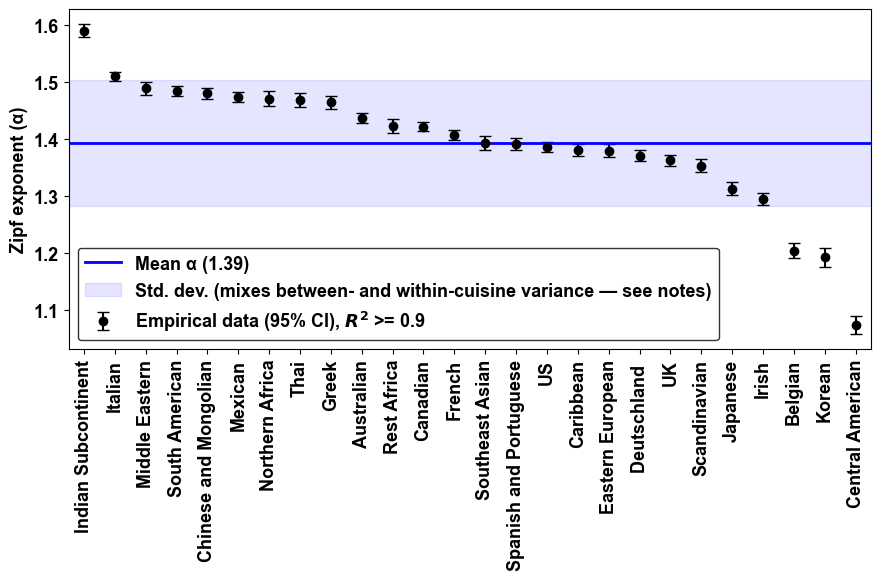

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13


def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")


# ==========================================
# Load data
# ==========================================
df_ing = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("Datasets/RecipeDB_RecipeID_Cuisine.csv")

df_merged = pd.merge(df_ing, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

cuisines = df_merged['Cuisine'].unique()
results = []
excluded_cuisines = []

print(f"Analyzing {len(cuisines)} cuisines...")
print()
print("NOTE ON METHOD: this cell uses OLS (scipy.stats.linregress) on")
print("log(rank) vs log(freq), the same approach flagged in the original")
print("single-cuisine Zipf cell for downward bias on |alpha| and equal")
print("weighting of high- and low-frequency ranks. The paper's reported")
print("values (global alpha~1.53, per-cuisine mean alpha~1.39, range")
print("1.075-1.590, Supplementary Table 6) were obtained via MLE with")
print("KS-minimised xmin, not OLS. Expect this cell's alpha values to run")
print("systematically LOWER than the paper's — that is the expected")
print("direction of OLS bias, not an error in this analysis. Report any")
print("such gap as a methodological discrepancy, not a replication failure.")
print()

# Minimum sample-size threshold for attempting a fit. Hardcoded like
# limit_head below; chosen as "enough points to draw a line through with
# any stability," not derived from any formal criterion. Flagged here so
# it's not silently invisible in the analysis.
MIN_FIT_POINTS = 5

for cuisine in cuisines:

    subset = df_merged[df_merged['Cuisine'] == cuisine]

    counts = subset['ing_id'].value_counts()

    freqs = counts.values
    ranks = np.arange(1, len(freqs) + 1)

    # Head-cutoff logic: still a hardcoded, two-valued choice (10 vs 0,
    # gated on vocabulary size > 50). This was NOT replaced with the
    # R²-peak method from the single-cuisine cell, because running that
    # search independently for all 26 cuisines would multiply the same
    # boundary-finding instability seen there by 26 — for a cross-cuisine
    # comparison, a CONSISTENT (if imperfect) cutoff rule is arguably more
    # defensible than 26 independently-optimised ones that could each
    # land on different parts of their own R² curve. This is a deliberate
    # trade-off, not an oversight — but it must be stated as a limitation:
    # the same fixed cutoff=10 excludes a much larger FRACTION of a small
    # cuisine's vocabulary than a large one's, so some of the cross-cuisine
    # spread plotted below may reflect this interaction rather than a
    # genuine difference in ingredient-usage concentration.
    limit_head = 10 if len(freqs) > 50 else 0
    mask = (ranks >= limit_head)

    frac_excluded_by_cutoff = limit_head / len(freqs) if len(freqs) > 0 else 0

    if np.sum(mask) > MIN_FIT_POINTS:

        log_ranks = np.log(ranks[mask])
        log_freqs = np.log(freqs[mask])

        slope, intercept, r_value, p_value, std_err = linregress(log_ranks, log_freqs)

        alpha = -slope
        alpha_ci_95 = 1.96 * std_err

        results.append({
            'Cuisine': cuisine,
            'Alpha': alpha,
            'Alpha_Low': alpha - alpha_ci_95,
            'Alpha_High': alpha + alpha_ci_95,
            'R_Squared': r_value ** 2,
            'N_unique_ingredients': len(freqs),
            'N_recipes': len(subset),
            'Head_cutoff_used': limit_head,
            'Frac_vocab_excluded_by_cutoff': frac_excluded_by_cutoff
        })

    else:
        excluded_cuisines.append((cuisine, np.sum(mask)))

if excluded_cuisines:
    print(f"Excluded {len(excluded_cuisines)} cuisine(s) for having "
          f"<= {MIN_FIT_POINTS} points above the head cutoff:")
    for name, n_pts in excluded_cuisines:
        print(f"  - {name}: only {n_pts} points available")
else:
    print("No cuisines excluded by the minimum sample-size threshold.")

df_results = pd.DataFrame(results).sort_values('Alpha', ascending=False)

# ==========================================
# R² reporting — flag, don't silently plot, poor fits
# ==========================================
R2_FLAG_THRESHOLD = 0.90  # paper reports ~0.95-0.97 across cuisines; flag
                           # anything notably below that range

poor_fits = df_results[df_results['R_Squared'] < R2_FLAG_THRESHOLD]
print()
if len(poor_fits) > 0:
    print(f"WARNING: {len(poor_fits)} cuisine(s) have R^2 < {R2_FLAG_THRESHOLD} "
          f"(paper's reported range is ~0.95-0.97):")
    for _, row in poor_fits.iterrows():
        print(f"  - {row['Cuisine']}: R^2={row['R_Squared']:.3f}, "
              f"alpha={row['Alpha']:.3f} (n_unique={row['N_unique_ingredients']})")
    print("  These fits are visually weighted the SAME as good fits in the")
    print("  plot below — treat their alpha values with extra caution.")
else:
    print(f"All retained cuisines have R^2 >= {R2_FLAG_THRESHOLD}.")

# ==========================================
# Variance decomposition note — between-cuisine vs within-cuisine
# ==========================================
mean_alpha = df_results['Alpha'].mean()
std_alpha = df_results['Alpha'].std()

print()
print("Variance note: 'Standard deviation across cuisines' (the shaded band")
print("below) mixes two sources of spread that are not separated here:")
print("  1. genuine between-cuisine variation in ingredient-usage concentration")
print("  2. within-cuisine estimation noise, which is itself larger for")
print("     cuisines with fewer recipes (e.g. small-n cuisines will have a")
print("     noisier alpha purely from sample size, not necessarily a truly")
print("     different underlying exponent)")
print("This is the same way the paper's own Fig. 2b presents this band (no")
print("deconvolution apparent in their Methods either), so it is not a")
print("unique flaw here — but the std-dev band should be read as an upper")
print("bound on TRUE cross-cuisine variability, not a clean estimate of it.")

# Check: does the smallest cuisine (by recipe count) show the widest CI?
# This is a sanity check that the CI construction is at least internally
# consistent with sample size, even though it rests on OLS/homoscedasticity
# assumptions that were never directly verified.
smallest_cuisine_row = df_results.loc[df_results['N_recipes'].idxmin()]
widest_ci_row = df_results.loc[
    (df_results['Alpha_High'] - df_results['Alpha_Low']).idxmax()
]
print()
print(f"Smallest cuisine by recipe count: {smallest_cuisine_row['Cuisine']} "
      f"(n={smallest_cuisine_row['N_recipes']})")
print(f"Cuisine with widest CI:           {widest_ci_row['Cuisine']} "
      f"(n={widest_ci_row['N_recipes']})")
if smallest_cuisine_row['Cuisine'] == widest_ci_row['Cuisine']:
    print("-> These match: the CI is correctly reflecting sample-size-driven")
    print("   uncertainty, which supports (but does not prove) internal")
    print("   consistency of the CI construction.")
else:
    print("-> These do NOT match. Worth checking whether some other factor")
    print("   (e.g. R^2, vocabulary size, head-cutoff fraction excluded) is")
    print("   driving CI width more than raw recipe count.")

# ==========================================
# Export full results (including diagnostics) to CSV
# ==========================================
df_results.to_csv("zipf_alpha_by_cuisine_OLS.csv", index=False)
print("\nFull per-cuisine results (including R^2, N, cutoff diagnostics) "
      "exported to zipf_alpha_by_cuisine_OLS.csv")

# ==========================================
# Plot
# ==========================================
fig, ax = plt.subplots(figsize=(9, 6))

x_positions = np.arange(len(df_results))

y_errs = [
    df_results['Alpha'] - df_results['Alpha_Low'],
    df_results['Alpha_High'] - df_results['Alpha']
]

# Empirical points — marker style now flags poor-R^2 fits visually instead
# of plotting every cuisine with identical visual weight regardless of fit
# quality.
is_poor_fit = (df_results['R_Squared'] < R2_FLAG_THRESHOLD).values

ax.errorbar(
    x_positions[~is_poor_fit],
    df_results['Alpha'][~is_poor_fit],
    yerr=[np.array(y_errs[0])[~is_poor_fit], np.array(y_errs[1])[~is_poor_fit]],
    fmt='o',
    capsize=4,
    color='black',
    label=f'Empirical data (95% CI), $R^2$ >= {R2_FLAG_THRESHOLD}'
)

if is_poor_fit.any():
    ax.errorbar(
        x_positions[is_poor_fit],
        df_results['Alpha'][is_poor_fit],
        yerr=[np.array(y_errs[0])[is_poor_fit], np.array(y_errs[1])[is_poor_fit]],
        fmt='o',
        capsize=4,
        color='red',
        markerfacecolor='white',
        label=f'Empirical data (95% CI), $R^2$ < {R2_FLAG_THRESHOLD} (caution)'
    )

# Mean line
ax.axhline(
    mean_alpha,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Mean α ({mean_alpha:.2f})'
)

# ---- FULL WIDTH STANDARD DEVIATION BAND ----
x_band = np.concatenate(([x_positions[0] - 0.5], x_positions, [x_positions[-1] + 0.5]))

lower_band = np.repeat(mean_alpha - std_alpha, len(x_band))
upper_band = np.repeat(mean_alpha + std_alpha, len(x_band))

ax.fill_between(
    x_band,
    lower_band,
    upper_band,
    color='blue',
    alpha=0.1,
    label='Std. dev. (mixes between- and within-cuisine variance — see notes)'
)

# Axis labels
ax.set_ylabel("Zipf exponent (α)", fontweight="bold")

ax.set_xticks(x_positions)
ax.set_xticklabels(df_results['Cuisine'], rotation=90)

# Remove margins so band touches edges
ax.margins(x=0)

format_axes(ax)

plt.tight_layout()

# Save figures
plt.savefig("zipf_alpha_by_cuisine.png", dpi=300)
plt.savefig("zipf_alpha_by_cuisine.tif", dpi=300)

plt.show()

Calculating Heaps β for 26 cuisines...

=== Heaps' Law β by Cuisine ===
               Cuisine   Beta  Lower_CI_95  Upper_CI_95  R_Squared  Num_Recipes
      Central American 0.6331       0.6223       0.6438     0.9917          455
                Korean 0.6173       0.6101       0.6244     0.9957          668
               Belgian 0.5982       0.5917       0.6047     0.9967         1060
                 Irish 0.5769       0.5718       0.5820     0.9978         2529
              Japanese 0.5554       0.5498       0.5611     0.9973         2040
             Caribbean 0.5553       0.5506       0.5601     0.9981         3023
               Mexican 0.5528       0.5507       0.5549     0.9996        14447
          Scandinavian 0.5522       0.5458       0.5586     0.9965         2811
                    UK 0.5492       0.5442       0.5543     0.9977         4396
          Deutschland  0.5488       0.5455       0.5521     0.9990         4321
                French 0.5459       0.5421      

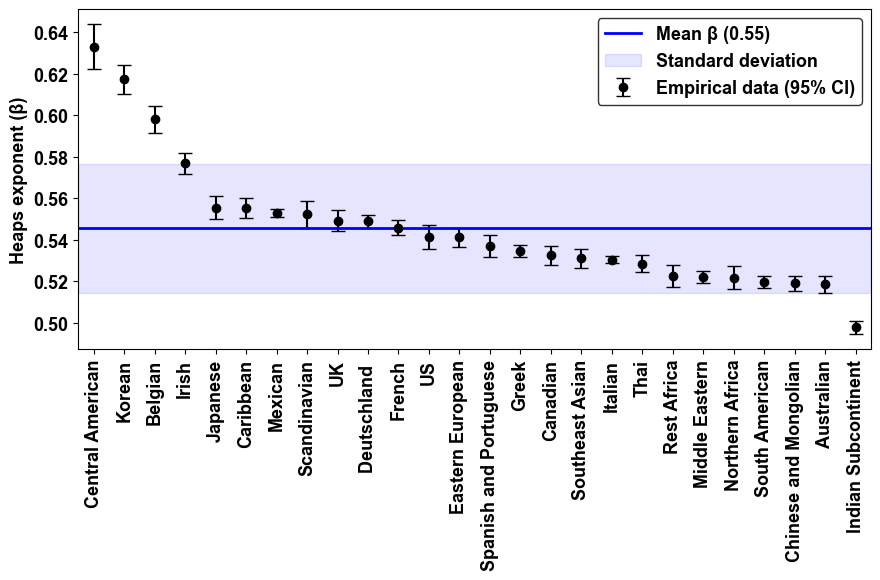

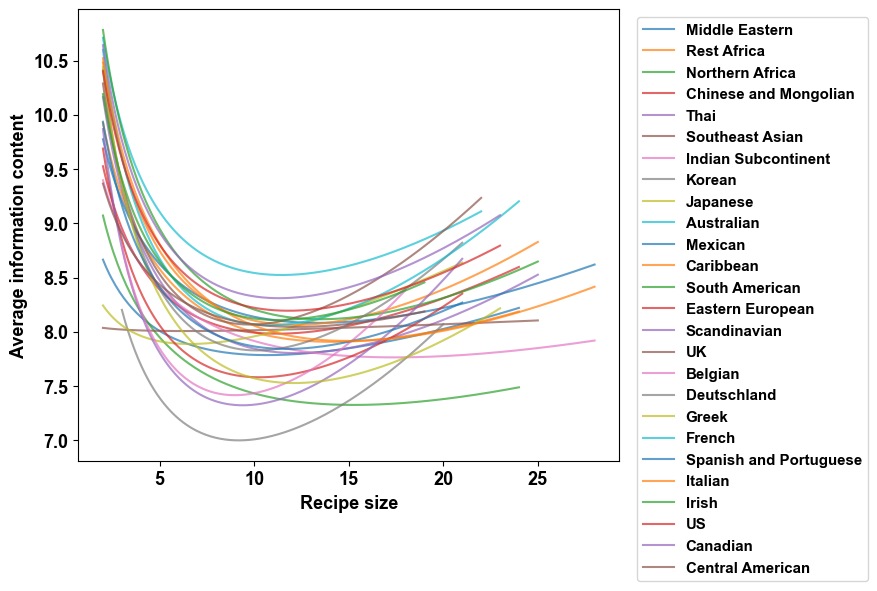


=== Menzerath–Altmann Parameters by Cuisine ===
               Cuisine         a         b         c    a_err    b_err    c_err
        Middle Eastern  9.226990 -0.124251 -0.011638 0.207670 0.018876 0.001941
           Rest Africa 11.121521 -0.206779 -0.014613 0.150252 0.011689 0.001233
       Northern Africa 10.058903 -0.183715 -0.012028 0.225384 0.019339 0.002038
 Chinese and Mongolian 10.536278 -0.195846 -0.017460 0.235298 0.019012 0.001976
                  Thai 11.731432 -0.270808 -0.022103 0.212478 0.015342 0.001567
       Southeast Asian  8.059111 -0.007731 -0.001219 0.259158 0.026219 0.002637
   Indian Subcontinent 10.243655 -0.149204 -0.008563 0.211543 0.016130 0.001497
                Korean 10.797615 -0.356305 -0.038814 0.630772 0.050040 0.005295
              Japanese  8.532354 -0.088665 -0.013438 0.231539 0.024772 0.002858
            Australian 12.182375 -0.248321 -0.021679 0.222094 0.016653 0.001874
               Mexican 10.787022 -0.181293 -0.013566 0.305882 0.022063 

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

# ---- Load & Merge Data ----
df_ing = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("Datasets/RecipeDB_RecipeID_Cuisine.csv")
df_merged = pd.merge(df_ing, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

# ---- Minimum recipes per cuisine ----
MIN_RECIPES = 50

cuisines = df_merged['Cuisine'].unique()
results_ma = []

def ma_model(x, A, b, c):
    return A * (x**b) * np.exp(-c * x)

fig, ax = plt.subplots(figsize=(9, 6))

for cuisine in cuisines:
    subset = df_merged[df_merged['Cuisine'] == cuisine].copy()

    # Skip cuisines with too few recipes for stable fitting
    n_recipes = subset['recipe_no'].nunique()
    if n_recipes < MIN_RECIPES:
        print(f"  Skipping {cuisine}: only {n_recipes} recipes (< {MIN_RECIPES})")
        continue

    # Local Information Content
    ing_counts = subset['ing_id'].value_counts()
    N = len(subset)
    probs = ing_counts / N
    subset['ic'] = -np.log2(subset['ing_id'].map(probs))

    # Mean IC per recipe
    recipe_stats = subset.groupby('recipe_no').agg(
        length=('ing_id', 'count'),
        mean_ic=('ic', 'mean')
    )

    # Mean-field averaging over recipe lengths
    ma_data = recipe_stats.groupby('length')['mean_ic'].mean().reset_index()

    # Keep only lengths with >= 5 recipes for stability
    counts = recipe_stats['length'].value_counts()
    valid_lengths = counts[counts >= 5].index
    ma_data = ma_data[ma_data['length'].isin(valid_lengths)].sort_values('length')

    if len(ma_data) <= 5:
        print(f"  Skipping {cuisine}: insufficient length bins after filtering")
        continue

    x_data = ma_data['length'].values
    y_data = ma_data['mean_ic'].values

    try:
        # Better initial guess: start near data, positive decay
        p0 = [y_data[0], -0.2, 0.01]

        popt, pcov = curve_fit(
            ma_model,
            x_data,
            y_data,
            p0=p0,
            maxfev=10000
        )
        perr = np.sqrt(np.diag(pcov))  # standard errors on each parameter

        results_ma.append({
            'Cuisine': cuisine,
            'a': popt[0], 'b': popt[1], 'c': popt[2],
            'a_err': perr[0], 'b_err': perr[1], 'c_err': perr[2]
        })

        x_line = np.linspace(min(x_data), max(x_data), 200)
        ax.plot(x_line, ma_model(x_line, *popt), alpha=0.7, label=cuisine)

    except Exception as e:
        print(f"  Fit failed for {cuisine}: {e}")

ax.set_xlabel("Recipe size", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")
ax.grid(False)

legend = ax.legend(
    frameon=True,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize='small'
)

plt.tight_layout()
plt.savefig("menzerath_altmann_cuisines.png", dpi=300)
plt.savefig("menzerath_altmann_cuisines.tif", dpi=300)
plt.show()

# ---- Parameter Table ----
df_params = pd.DataFrame(results_ma)
print("\n=== Menzerath–Altmann Parameters by Cuisine ===")
print(df_params.to_string(index=False))

df_params.to_csv("menzerath_altmann_parameters_by_cuisine.csv", index=False)
print("\nParameters exported to: menzerath_altmann_parameters_by_cuisine.csv")

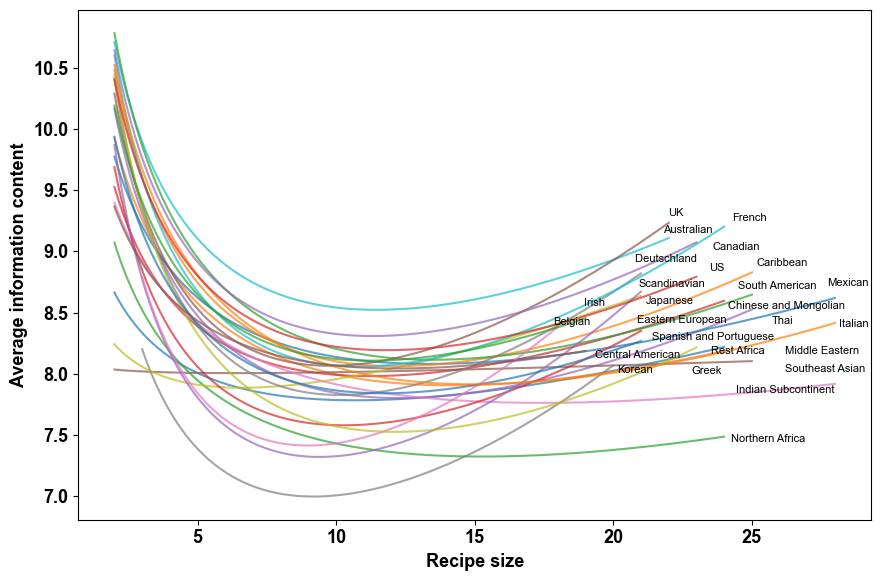

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from adjustText import adjust_text

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

# ---- Load & Merge Data ----
df_ing = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("Datasets/RecipeDB_RecipeID_Cuisine.csv")
df_merged = pd.merge(df_ing, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

# ---- Minimum recipes per cuisine ----
MIN_RECIPES = 50

cuisines = df_merged['Cuisine'].unique()

def ma_model(x, A, b, c):
    return A * (x**b) * np.exp(-c * x)

fig, ax = plt.subplots(figsize=(9, 6))
texts = []  # collect label objects for adjustText

for cuisine in cuisines:
    subset = df_merged[df_merged['Cuisine'] == cuisine].copy()

    n_recipes = subset['recipe_no'].nunique()
    if n_recipes < MIN_RECIPES:
        print(f"  Skipping {cuisine}: only {n_recipes} recipes (< {MIN_RECIPES})")
        continue

    ing_counts = subset['ing_id'].value_counts()
    N = len(subset)
    probs = ing_counts / N
    subset['ic'] = -np.log2(subset['ing_id'].map(probs))

    recipe_stats = subset.groupby('recipe_no').agg(
        length=('ing_id', 'count'),
        mean_ic=('ic', 'mean')
    )

    ma_data = recipe_stats.groupby('length')['mean_ic'].mean().reset_index()

    counts = recipe_stats['length'].value_counts()
    valid_lengths = counts[counts >= 5].index
    ma_data = ma_data[ma_data['length'].isin(valid_lengths)].sort_values('length')

    if len(ma_data) <= 5:
        print(f"  Skipping {cuisine}: insufficient length bins after filtering")
        continue

    x_data = ma_data['length'].values
    y_data = ma_data['mean_ic'].values

    try:
        p0 = [y_data[0], -0.2, 0.01]

        popt, pcov = curve_fit(
            ma_model,
            x_data,
            y_data,
            p0=p0,
            maxfev=10000
        )

        x_line = np.linspace(min(x_data), max(x_data), 200)
        y_line = ma_model(x_line, *popt)

        ax.plot(x_line, y_line, alpha=0.7)

        # Collect label — adjustText will resolve overlaps after the loop
        texts.append(ax.text(
            x_line[-1], y_line[-1],
            cuisine,
            fontsize=8,
            fontweight='normal',
            va='center'
        ))

    except Exception as e:
        print(f"  Fit failed for {cuisine}: {e}")

# Automatically nudge overlapping labels apart — no hardcoded shifts needed
adjust_text(texts, ax=ax)

ax.set_xlabel("Recipe size", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")
ax.grid(False)

plt.tight_layout()
plt.savefig("menzerath_altmann_cuisines_labeled.png", dpi=300)
plt.savefig("menzerath_altmann_cuisines_labeled.tif", dpi=300)
plt.show()

## Cell 5 — Menzerath–Altmann Law by Cuisine

Fits a **Menzerath–Altmann (MA) model** to each cuisine independently, asking whether
longer recipes tend to use lower-information (more predictable) ingredients on average.

### Model

$$\langle IC \rangle(L) = A \cdot L^{b} \cdot e^{-cL}$$

| Parameter | Role |
|-----------|------|
| $A$ | amplitude (overall IC scale) |
| $b$ | power-law growth at short lengths |
| $c$ | exponential decay at long lengths |

The interplay of $b$ and $c$ determines whether IC peaks early and falls off
(classic MA behaviour) or rises monotonically within the observed range.

### Pipeline

1. **Merge** ingredient and cuisine tables on `recipe_no` / `Recipe_id`.
2. **Local IC** — ingredient probabilities are computed *within* each cuisine, so
   information content is relative to that cuisine's own lexicon.
3. **Mean-field average** — for each recipe length $L$, average $\langle IC \rangle$
   across all recipes of that length.
4. **Stability filter** — lengths represented by fewer than 5 recipes are dropped;
   cuisines with fewer than 50 recipes are skipped entirely.
5. **Curve fit** — `scipy.optimize.curve_fit` with initial guess
   $[y_0,\ -0.2,\ 0.01]$ anchored to the first data point.
6. **Uncertainty** — `pcov` diagonal gives standard errors on $A$, $b$, $c$;
   stored alongside point estimates in the exported CSV.

### Outputs

| File | Contents |
|------|----------|
| `menzerath_altmann_cuisines.png / .tif` | MA curves, one colour per cuisine, external legend (Cell 5a) |
| `menzerath_altmann_cuisines_labeled.png / .tif` | Same curves, inline cuisine labels de-overlapped by `adjustText` (Cell 5b) |
| `menzerath_altmann_parameters_by_cuisine.csv` | $A, b, c$ and their standard errors for every successfully fitted cuisine |

### Notes

- Fits that fail (singular covariance, convergence timeout, etc.) print a warning
  with the cuisine name and the exact `scipy` error — they are excluded from the
  plot and CSV rather than silently dropped.
- Cell 5a and 5b run the same fitting loop; 5b replaces the external legend with
  `adjustText` inline labels and omits the parameter export (already done in 5a).
- Parameter uncertainties in the CSV allow downstream filtering of poorly
  constrained fits (e.g. discard rows where `a_err / a > 0.5`).